<a href="https://colab.research.google.com/github/ashhwiithac22/Deep-Learning-Experiments/blob/main/DL_Ex10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1, Loss: 317.3297
Epoch 2, Loss: 145.7625
Epoch 3, Loss: 100.7248
Epoch 4, Loss: 77.1536
Epoch 5, Loss: 60.4599
Epoch 6, Loss: 48.7141
Epoch 7, Loss: 40.8850
Epoch 8, Loss: 32.7051
Epoch 9, Loss: 26.7327
Epoch 10, Loss: 22.8321

Test Accuracy: 97.66%


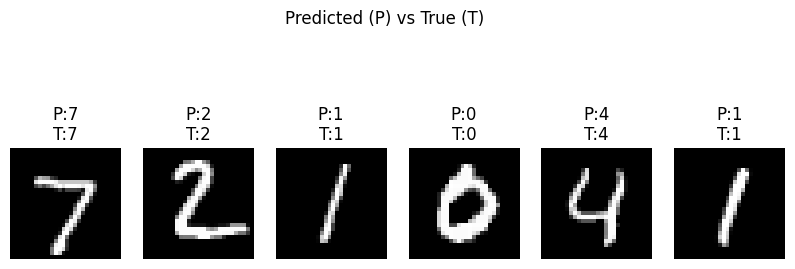

In [4]:
'''MNIST consists of 70,000 gray images
resolution is 28*28 pixels
Linear transformation means, multiply inputs by weights and add bias
'''
import torch #used to train neural networks
import torch.nn as nn #contains layers like relu
import torch.optim as optim #import optimization algorityhms
import torchvision
import torchvision.transforms as transforms # to converts images to tensor format
import matplotlib.pyplot as plt

transform = transforms.ToTensor() #converts images to tensor format

train_data = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True) #splits data into 64 batches and shuffles training data
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64) #creates batches for testing

class MLP(nn.Module): #creates a neural network class
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128) #input image = 28*28 and 128 neurons
        self.relu = nn.ReLU() #non linearity, helps to learn complex patterns
        self.fc2 = nn.Linear(128, 10) #output layer -> 128 neurons and 0 - 9 digits(10)

    def forward(self, x):
        x = x.view(-1, 28*28) #images in 2D, MLP needs 1D so it flattens
        x = self.relu(self.fc1(x))
        x = self.fc2(x) #produces final output
        return x

model = MLP()
criterion = nn.CrossEntropyLoss() #Loss function for classification, measures prediction error
optimizer = optim.Adam(model.parameters(), lr=0.001) #adam optimization algorithm

epochs = 10 #training repeats 10 times
for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader: #loads one batch at a time
        outputs = model(images) #model makes predictions
        loss = criterion(outputs, labels) #computes error between predicted and actual

        optimizer.zero_grad() #clears old gradients
        loss.backward() #backpropagation
        optimizer.step() #updates weights

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
correct = 0
total = 0

with torch.no_grad(): #turns off gradient calculation
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) #finds highest score

        total += labels.size(0) #count total labels
        correct += (predicted == labels).sum().item() #count correct predictions

accuracy = 100 * correct / total
print(f"\nTest Accuracy: {accuracy:.2f}%")

dataiter = iter(test_loader) #gets one batch from test image
images, labels = next(dataiter)

outputs = model(images)
_, predicted = torch.max(outputs, 1) #model predicts digits
plt.figure(figsize=(10,4))

for i in range(6): #showes first 6 imag
    plt.subplot(1,6,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray") #squeeze is used to remove extra dimensions
    plt.title(f"P:{predicted[i].item()}\nT:{labels[i].item()}")
    plt.axis("off")

plt.suptitle("Predicted (P) vs True (T)")
plt.show()